In [3]:
import pandas as pd
train_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Train/Trainset_dataset1.xlsx"
test_yield_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/refs/heads/main/Datasets/Test/Testset_dataset1%20(1).csv"
test_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Test/Testset_feature_dataset1.xlsx"

df_train = pd.read_excel(train_url)
df_test = pd.read_excel(test_url)
df_test_feature = pd.read_csv(test_yield_url)
df_train.info()
#df_train.head()
df_test.info()
df_test_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Ash(wt%)                   747 non-null    float64
 1   FixedCarbon(wt%)           747 non-null    float64
 2   Volatiles(wt%)             747 non-null    float64
 3   C(wt%)                     845 non-null    float64
 4   H(wt%)                     835 non-null    float64
 5   O(wt%)                     835 non-null    float64
 6   N(wt%)                     805 non-null    float64
 7   H/C                        835 non-null    float64
 8   Cellulose(wt%)             669 non-null    float64
 9   Hemicellulose(wt%)         483 non-null    float64
 10  Lignin(wt%)                510 non-null    float64
 11  T(^C)                      845 non-null    int64  
 12  HeatingRate(^C/min)        845 non-null    int64  
 13  ParticleSize(mm)           845 non-null    float64

Understanding the data

In [4]:
df_train.shape #how big is the data?
df_train.describe()# datatype of each column




,Ash(wt%),FixedCarbon(wt%),Volatiles(wt%),C(wt%),H(wt%),O(wt%),N(wt%),H/C,Cellulose(wt%),Hemicellulose(wt%),Lignin(wt%),T(^C),HeatingRate(^C/min),ParticleSize(mm),FlowRate-Nitrogen(ml/min),yield(wt%)
count,747.000000,747.000000,747.000000,845.000000,835.000000,835.000000,805.000000,835.000000,669.000000,483.000000,510.000000,845.000000,845.000000,845.000000,845.000000,845.000000
mean,5.623498,16.034171,78.342330,49.267011,6.482051,40.598446,2.933221,0.121796,34.156218,27.509151,22.667353,514.674556,65.073373,0.812234,125.177515,40.478817
std,3.778697,8.540413,9.971436,6.705218,1.155756,8.613152,2.551525,0.041311,11.559224,10.709667,11.559443,90.715530,112.020190,0.526874,242.063168,9.902880
min,0.278552,0.107181,10.855927,19.490000,2.410000,10.490000,0.170000,0.100000,5.750000,3.400000,0.800000,300.000000,5.000000,0.100000,0.000000,11.000000
25%,2.332980,11.981198,75.774742,44.820000,5.890000,34.190000,0.920000,0.100000,27.200000,19.400000,15.000000,450.000000,7.000000,0.450000,0.000000,33.000000
50%,5.245536,14.880575,78.747204,47.400000,6.230000,41.630000,2.050000,0.100000,32.060000,25.520000,26.110000,500.000000,20.000000,0.650000,100.000000,40.300000
75%,7.286460,17.114094,83.102511,52.900000,6.735700,48.280000,4.400000,0.100000,43.000000,36.550000,30.100000,550.000000,50.000000,1.000000,100.000000,47.800000
max,40.084388,78.545821,95.984215,79.770000,10.590000,54.120000,9.290000,0.200000,60.270000,51.340000,50.400000,900.000000,800.000000,3.200000,2000.000000,77.200000


Find out Total Missing values of each column

In [5]:
print(df_train.isnull().sum())
print()
print(df_test.isnull().sum())

Ash(wt%)                      98
FixedCarbon(wt%)              98
Volatiles(wt%)                98
C(wt%)                         0
H(wt%)                        10
O(wt%)                        10
N(wt%)                        40
H/C                           10
Cellulose(wt%)               176
Hemicellulose(wt%)           362
Lignin(wt%)                  335
T(^C)                          0
HeatingRate(^C/min)            0
ParticleSize(mm)               0
FlowRate-Nitrogen(ml/min)      0
yield(wt%)                     0
dtype: int64

Ash(wt%)                     28
FixedCarbon(wt%)             28
Volatiles(wt%)               28
C(wt%)                        0
H(wt%)                        5
O(wt%)                        5
N(wt%)                       11
H/C                           5
Cellulose(wt%)               49
Hemicellulose(wt%)           83
Lignin(wt%)                  77
T(^C)                         0
HeatingRate(^C/min)           0
ParticleSize(mm)              0
FlowRate-N

In [6]:
print(df_train.duplicated().sum())
#df_train[df_train.duplicated()] # Print the duplicates
df_train.drop_duplicates(inplace=True)
print(df_train.duplicated().sum())

37
0


In [ ]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
prof=ProfileReport(df_train)
prof.to_file(output_file='output_train.html')
prof=ProfileReport(df_test)
prof.to_file(output_file='output_test.html')
prof=ProfileReport(df_test_feature)
prof.to_file(output_file='output_test_feature.html')

EDA

Univariant Analysis


(array([  5.,  36., 105., 185., 205., 144.,  91.,  35.,   1.,   1.]),
 array([11.  , 17.62, 24.24, 30.86, 37.48, 44.1 , 50.72, 57.34, 63.96,
        70.58, 77.2 ]),
 <BarContainer object of 10 artists>)

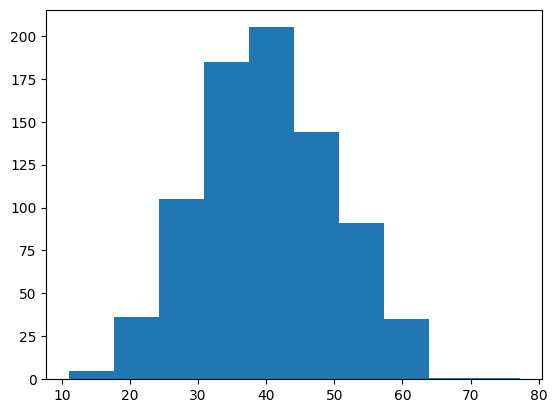

In [8]:
import matplotlib.pyplot as plt
plt.hist(df_train['yield(wt%)'])

# Handling Missing Data

In [9]:
#Using KNN Imputers
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=3)
x_train=df_train.drop(columns=['yield(wt%)'])
y_train=df_train['yield(wt%)']
x_train=pd.DataFrame(imputer.fit_transform(x_train),columns=x_train.columns)
x_test=pd.DataFrame(imputer.fit_transform(df_test),columns=df_test.columns)
#df_test_feature=pd.DataFrame(imputer.fit_transform(df_test_feature),columns=df_test_feature.columns)

In [10]:
print(x_train.isnull().sum())
print()
print(x_test.isnull().sum())

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64


# Outlier Detection

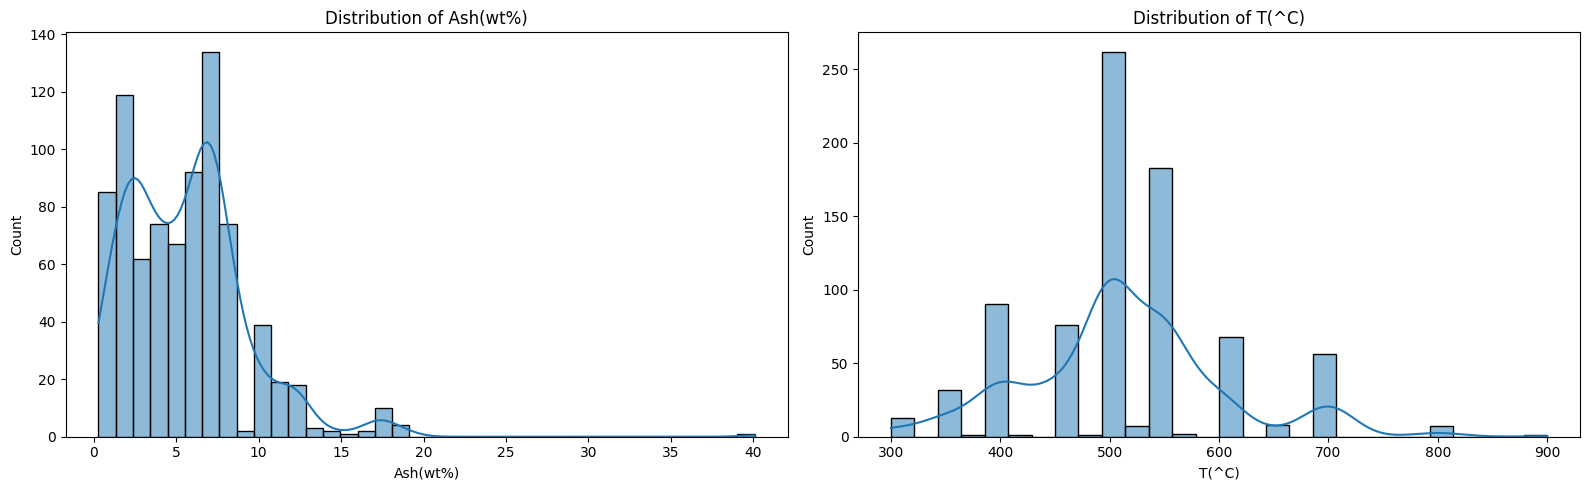

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better visibility
plt.figure(figsize=(16, 5))

# Subplot 1
plt.subplot(1, 2, 1)
sns.histplot(x_train['Ash(wt%)'], kde=True)
plt.title('Distribution of Ash(wt%)')

# Subplot 2
plt.subplot(1, 2, 2)
sns.histplot(x_train['T(^C)'], kde=True)
plt.title('Distribution of T(^C)')

plt.tight_layout()
plt.show()

In [12]:
#Normal distribution, Skewed distribution (for skewed data)
#Zscore , IQR based filtering, percentile, Winsorization

#Right Skewed
print(x_train['Ash(wt%)'].skew())
print(x_train['C(wt%)'].skew())
print(x_train['Cellulose(wt%)'].skew())
print(x_train['FixedCarbon(wt%)'].skew())

1.724731987018256
1.1474474168753819
0.07019267499124901
4.755496298749928


Boxplot of each features

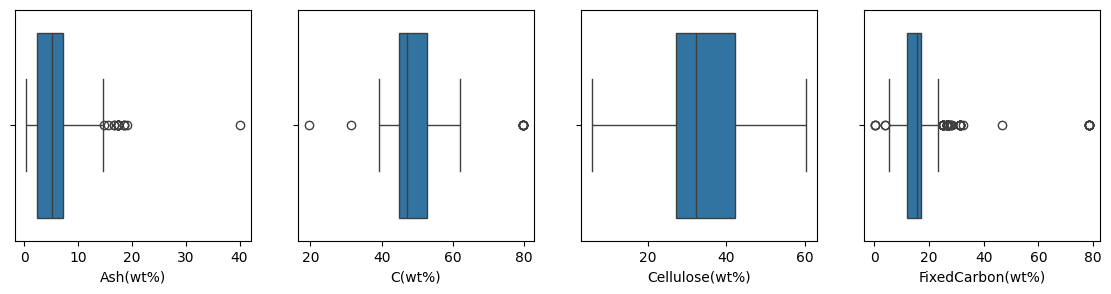

In [13]:
plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train['FixedCarbon(wt%)'])
plt.show()


Finding the IQR for each feature


In [14]:
from numpy import percentile

# Dictionary to store outlier counts
outlier_counts = {}
value_limits={}

for col in x_train.columns:
    q1 = x_train[col].quantile(0.25)
    q3 = x_train[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    value_limits[col]=[lower_limit,upper_limit]

    # Count outliers
    num_outliers = x_train[(x_train[col] < lower_limit) | (x_train[col] > upper_limit)].shape[0]
    outlier_counts[col] = num_outliers

# Convert to Series for better display
outlier_summary = pd.Series(outlier_counts)
print("Total Outliers per Feature:")
print(outlier_summary)
print()
print("Value Limits per Feature:")
print(value_limits)

### Test set ###
outlier_counts_test = {}
value_limits_test={}

for col in x_test.columns:
    q1 = x_test[col].quantile(0.25)
    q3 = x_test[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    value_limits_test[col]=[lower_limit,upper_limit]

    # Count outliers
    num_outliers_test = x_train[(x_train[col] < lower_limit) | (x_train[col] > upper_limit)].shape[0]
    outlier_counts_test[col] = num_outliers_test

print()
outlier_summary = pd.Series(outlier_counts_test)
print("Total Outliers per Feature:")
print(outlier_summary)
print()
print("Value Limits per Feature:")
print(value_limits_test)

Total Outliers per Feature:
Ash(wt%)                      19
FixedCarbon(wt%)              65
Volatiles(wt%)                48
C(wt%)                        11
H(wt%)                       117
O(wt%)                         9
N(wt%)                         0
H/C                          183
Cellulose(wt%)                 0
Hemicellulose(wt%)             1
Lignin(wt%)                    0
T(^C)                          8
HeatingRate(^C/min)          114
ParticleSize(mm)              37
FlowRate-Nitrogen(ml/min)     73
dtype: int64

Value Limits per Feature:
{'Ash(wt%)': [np.float64(-5.097240474454769), np.float64(14.716680394858349)], 'FixedCarbon(wt%)': [np.float64(4.286441244920252), np.float64(24.810685588618245)], 'Volatiles(wt%)': [np.float64(65.64773596082011), np.float64(92.65308473929741)], 'C(wt%)': [np.float64(32.7), np.float64(65.02)], 'H(wt%)': [np.float64(4.621449999999999), np.float64(8.004249999999999)], 'O(wt%)': [np.float64(12.205000000000002), np.float64(69.925)], 'N(w

Capping

In [ ]:
x_train_copy = x_train.copy()

# Apply capping using the limits stored in value_limits
for col in x_train_copy.columns:
    lower, upper = value_limits[col]
    x_train_copy[col] = x_train_copy[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train_copy['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train_copy['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train_copy['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train_copy['FixedCarbon(wt%)'])
plt.show()

x_test_copy = x_test.copy()

# Apply capping using the limits stored in value_limits
for col in x_test_copy.columns:
    lower, upper = value_limits_test[col]
    x_test_copy[col] = x_test_copy[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_test_copy['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_test_copy['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_test_copy['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_test_copy['FixedCarbon(wt%)'])
plt.show()

Investigating Constants

In [ ]:
import numpy as np

# Check unique values in capped data
unique_counts = x_train_copy.nunique()
print("Unique values per feature after capping:")
print(unique_counts)

# Identify columns that became constant
constant_cols = unique_counts[unique_counts <= 1].index.tolist()
print(f"\nConstant columns to consider dropping: {constant_cols}")

### Dropping Constant Features Since `H/C` became a constant value after capping, it contains no information for the model. We will drop it from both the training and test sets.
x_train_copy.describe()
# Drop the constant column from training sets
x_train_capped = x_train_copy.drop(columns=['H/C'])
x_test_capped = x_test_copy.drop(columns=['H/C'])

print(f"Remaining features: {list(x_train_capped.columns)}")
print(f"Remaining features: {list(x_test_capped.columns)}")

# Feature Scaling
Standard Scaler

In [24]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fitting the scaler to the training set to learn the parameter
scaler.fit(x_train_capped)
#Now transform the train set
x_train_scaled=scaler.transform(x_train_capped)

#above step will return numpy array so we need to transform this to DataFrame
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train_capped.columns)
x_train_scaled.describe()

scaler.fit(x_test_capped)
x_test_scaled=scaler.transform(x_test_capped)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test_capped.columns)
x_test_scaled.describe()

#Standardization used for K Means, KNN, ANN, GD and PCA
#algo which uses distance to measure similarity which will affect when the data is having huge range difference, so we need to regularize

,Ash(wt%),FixedCarbon(wt%),Volatiles(wt%),C(wt%),H(wt%),O(wt%),N(wt%),Cellulose(wt%),Hemicellulose(wt%),Lignin(wt%),T(^C),HeatingRate(^C/min),ParticleSize(mm),FlowRate-Nitrogen(ml/min)
count,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02,2.120000e+02
mean,-1.340647e-16,-2.681293e-16,1.674761e-15,1.550123e-15,-2.781842e-15,-1.298751e-16,-1.508228e-16,-3.016455e-16,5.027425e-17,-1.173066e-16,-1.214961e-16,-1.110223e-16,5.027425e-16,1.026433e-16
std,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00,1.002367e+00
min,-1.547268e+00,-2.439064e+00,-2.157330e+00,-1.657934e+00,-1.817164e+00,-3.167423e+00,-1.056147e+00,-2.682283e+00,-2.568672e+00,-2.560173e+00,-2.091416e+00,-9.673135e-01,-1.374205e+00,-1.167327e+00
25%,-8.786768e-01,-6.536402e-01,-5.619145e-01,-7.934884e-01,-4.619830e-01,-7.820829e-01,-8.130231e-01,-6.416729e-01,-7.224691e-01,-8.011507e-01,-4.653273e-01,-8.308546e-01,-5.981166e-01,-1.167327e+00
50%,4.542789e-02,-2.425999e-02,-8.595078e-02,-1.987206e-01,-1.938375e-01,1.304204e-01,-3.306342e-01,5.311931e-02,-1.268745e-01,2.198087e-01,-4.838145e-02,-2.850189e-01,-2.646411e-01,7.750863e-02
75%,4.901871e-01,5.366427e-01,5.016957e-01,6.660604e-01,4.414713e-01,8.081438e-01,4.421528e-01,8.111033e-01,6.177946e-01,5.695245e-01,6.187319e-01,2.608168e-01,6.145215e-01,7.750863e-02
max,2.543483e+00,2.322067e+00,2.097111e+00,2.855384e+00,1.796653e+00,1.513854e+00,2.324917e+00,2.098725e+00,2.487906e+00,2.006834e+00,2.244821e+00,1.898324e+00,2.433479e+00,1.944762e+00


# Multiple Linear Regression Model

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

reg=LinearRegression()
reg.fit(x_train_scaled,y_train)
y_pred=reg.predict(x_test_scaled)
print(y_pred)


[39.64333657 40.3746737  32.70274033 38.31023176 37.5306799  32.53556072
 49.94277769 31.97870526 32.93433018 39.67105307 41.95301263 40.8918033
 44.9861905  50.53112334 48.6759594  33.5853397  34.93956925 35.02205778
 35.1045463  34.3015777  41.18339266 41.51334677 42.32165436 42.48663142
 44.30124155 34.86767904 35.39556563 36.4513388  35.43297766 42.09743058
 41.81206319 39.18289203 40.19531345 41.44993456 33.54829348 35.93236345
 36.76632361 35.20806818 46.03148254 48.84415707 50.4146928  42.01498891
 47.81727929 41.91937391 41.50752466 41.84829322 42.76945511 35.13552499
 36.6732913  39.30795128 49.47596684 53.13688327 44.23486564 37.10672371
 40.23735969 37.63407313 34.4796078  35.53538097 36.59115414 37.96698087
 42.71955921 38.40596784 54.50907436 36.77399591 34.45019447 33.99611092
 35.47933034 42.97843689 40.36524256 41.9887909  44.70897916 44.4737366
 32.38415804 42.61545443 35.1597715  33.40701157 33.78327601 29.6825354
 30.34764396 41.73352154 46.96076402 47.66901759 32.74

R Squared Error and Mean Absolute Error

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Extract the ground truth values
y_actual = df_test_feature['yield']

# 2. Calculate Evaluation Metrics
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.2f}")

# 3. Create a Comparison DataFrame
comparison_df = pd.DataFrame({'Actual': y_actual, 'Predicted': y_pred})
print("\nFirst 5 Comparisons:")
print(comparison_df.head())

# 4. Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.5, color='blue')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs Predicted Biofuel Yield (Linear Regression)')
plt.grid(True)
plt.show()